Python has a couple of built in functions and methods for sorting lists and other iterable objects.

Sorted function accepts a list and returns a sorted version of it

In [1]:
l = [3,1,4,8,0,5,2,8,4]
sorted(l)

[0, 1, 2, 3, 4, 4, 5, 8, 8]

In [3]:
l.sort()
print(l)

[0, 1, 2, 3, 4, 4, 5, 8, 8]


## Fast Sorting in Numpy: np.sort and np.argsort

In [4]:
import numpy as np

x = np.array([2, 1, 4, 3, 5])
np.sort(x)

array([1, 2, 3, 4, 5])

The **np.sort** function is analogous to python built in **sorted** function

In [5]:
i = np.argsort(x)
print(i)

[1 0 3 2 4]


A related function is argsort, which instead return the **indices** of the sorted elements

## Sorting along Rows or Columns

In [6]:
# we can sort multidimensional array using the *axis* argument

rng = np.random.default_rng(seed=1071)
x = rng.integers(0, 10, (4,6))
print(x)

[[7 2 1 8 3 2]
 [9 9 0 3 8 8]
 [6 1 2 3 5 8]
 [6 4 6 5 1 8]]


In [7]:
np.sort(x, axis=0)

array([[6, 1, 0, 3, 1, 2],
       [6, 2, 1, 3, 3, 8],
       [7, 4, 2, 5, 5, 8],
       [9, 9, 6, 8, 8, 8]])

In [8]:
np.sort(x, axis=1)

array([[1, 2, 2, 3, 7, 8],
       [0, 3, 8, 8, 9, 9],
       [1, 2, 3, 5, 6, 8],
       [1, 4, 5, 6, 6, 8]])

## Partial Sorting

In [9]:
x = np.array([7,2,5,1,3,6])
np.partition(x, 3)

array([1, 2, 3, 5, 6, 7])

np.partition takes an array and a number k; the result is a new array with smallest k value to the left of the partition and the remaining value to the right

## K-Nearest Neighbours

In [10]:
x = rng.random((10,2))

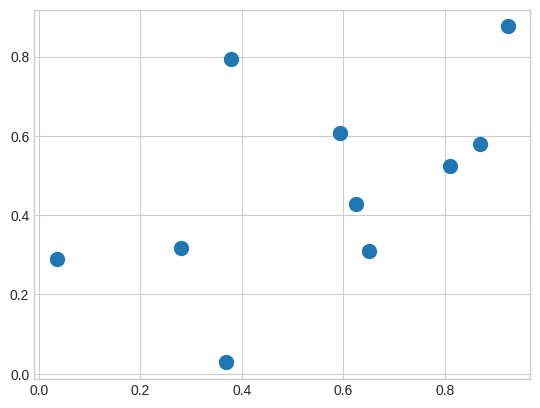

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(x[:, 0], x[:, 1], s=100)

In [12]:
dist_sq = np.sum((x[:, np.newaxis] - x[np.newaxis, :]) ** 2, axis=-1)

In [13]:
# for each pair of points, compute differences in their coordinates
diff = x[:, np.newaxis, :] - x[np.newaxis,  :]
diff.shape

(10, 10, 2)

In [14]:
sq_diff = diff ** 2
sq_diff.shape

(10, 10, 2)

In [15]:
# sum the coordinate differences to get the squared distance
dist_sq = sq_diff.sum(-1)
dist_sq.shape

(10, 10)

In [16]:
# the diagonal matrix
dist_sq.diagonal()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
nearest = np.argsort(dist_sq, axis=1)
print(nearest)

[[0 4 7 2 3 5 1 6 8 9]
 [1 2 6 8 3 5 9 4 7 0]
 [2 5 1 6 8 4 3 7 9 0]
 [3 1 2 4 6 8 9 5 0 7]
 [4 0 7 2 5 1 3 6 8 9]
 [5 2 6 1 8 4 7 3 0 9]
 [6 8 2 1 5 9 3 4 7 0]
 [7 4 5 0 2 1 6 8 3 9]
 [8 6 1 2 9 5 3 4 7 0]
 [9 8 6 1 2 3 5 4 7 0]]


In [18]:
k =  2
nearest_partition = np.argpartition(dist_sq, k, axis=1)
print(nearest_partition)

[[0 4 7 2 3 5 1 6 8 9]
 [1 2 6 8 3 5 9 4 7 0]
 [2 5 1 6 8 4 3 7 9 0]
 [3 1 2 4 6 8 9 5 0 7]
 [4 0 7 2 5 1 3 6 8 9]
 [5 2 6 1 8 4 7 3 0 9]
 [6 8 2 1 5 9 3 4 7 0]
 [7 4 5 0 2 1 6 8 3 9]
 [8 6 1 2 9 5 3 4 7 0]
 [9 8 6 1 2 3 5 4 7 0]]


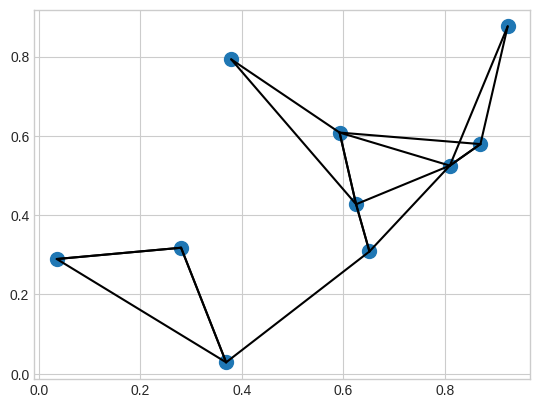

In [19]:
plt.scatter(x[:, 0], x[:, 1], s=100)

# draw each line from each points
k = 2
for i in range(x.shape[0]):
    for j in nearest_partition[i, :k+1]:
      plt.plot(*zip(x[j], x[i]), color='black')